# Multi-Class CNN Lab (PyTorch)

**Course:** Introduction to Deep Learning  
**Topic:** Multi-class image classification with CNNs  
**Format:** lab session (3h-4h)

In this lab, you will build and compare several CNN approaches for an **8-class clothing classification task**.

You will:
- inspect the dataset
- build a baseline CNN from scratch
- evaluate the model on the validation set
- reduce overfitting with data augmentation
- apply transfer learning
- fine-tune a pre-trained model
- predict classes for **unlabeled test images**

# Learning Objectives

By the end of this lab, you should be able to:

- explain why CNNs are effective for image classification
- train a multiclass CNN from scratch
- interpret learning curves and detect overfitting
- evaluate a model using confusion matrices and classification reports **when labels are available**
- use data augmentation appropriately
- apply transfer learning with a pre-trained model
- fine-tune part of a pre-trained model for better performance
- predict classes for previously unseen **unlabeled** images

# Dataset Structure

Download the image dataset "data_clothes.zip" available here: https://drive.google.com/file/d/1M1sD4DKg1_7zk6xgAIMbPG9y2pPYPc7R/view?usp=sharing.
This dataset contains 8 categories of images distributed as shown in the following structure (in total 22 directories):

```text
data/
├── train/
│   ├── accessories/
│   ├── jackets/
│   ├── jeans/
│   ├── knitwear/
│   ├── shirts/
│   ├── shoes/
│   ├── shorts/
│   └── tees/
├── validation/
│   ├── accessories/
│   ├── jackets/
│   ├── jeans/
│   ├── knitwear/
│   ├── shirts/
│   ├── shoes/
│   ├── shorts/
│   └── tees/
└── test/
    └── unknown/
        ├── image1.jpg
        ├── image2.jpg
        └── ...
```

In [1]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V2_Weights
from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu128
Using device: cuda


In [2]:
np.random.seed(42)
torch.manual_seed(42)

# Part 1 — Load and Inspect the Dataset

We start by checking that the directories exist and that the dataset is structured correctly.

In [3]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# The image dataset is expected as a zip file in your Google Drive
from zipfile import ZipFile
file_name = "/content/drive/MyDrive/AIM/TPs/Data_TP/data_clothes.zip"

with ZipFile(file_name, 'r') as zip_ref:
  zip_ref.extractall("data_clothes")
  print('Done')

Done


In [5]:
base_dir = "data_clothes"

train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "valid")
unknown_test_dir = os.path.join(base_dir, "test", "unknown")

print("Train exists:", os.path.exists(train_dir))
print("Validation exists:", os.path.exists(validation_dir))
print("Unknown test exists:", os.path.exists(unknown_test_dir))

Train exists: True
Validation exists: True
Unknown test exists: True


In [6]:
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
class_names

['accessories',
 'jackets',
 'jeans',
 'knitwear',
 'shirts',
 'shoes',
 'shorts',
 'tees']

In [7]:
print("Number of classes:", len(class_names))
print("Classes:", class_names)

Number of classes: 8
Classes: ['accessories', 'jackets', 'jeans', 'knitwear', 'shirts', 'shoes', 'shorts', 'tees']


In [8]:
def count_images_in_directory(directory):
    counts = {}
    total = 0
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            n = len([f for f in os.listdir(class_path) if not f.startswith(".")])
            counts[class_name] = n
            total += n
    return counts, total

train_counts, train_total = count_images_in_directory(train_dir)
val_counts, val_total = count_images_in_directory(validation_dir)

print("Train total:", train_total)
print(train_counts)
print()
print("Validation total:", val_total)
print(val_counts)

unknown_files = sorted([f for f in os.listdir(unknown_test_dir) if not f.startswith(".")])
print()
print("Unknown test images:", len(unknown_files))
print(unknown_files[:10])

Train total: 3467
{'accessories': 265, 'jackets': 282, 'jeans': 234, 'knitwear': 248, 'shirts': 291, 'shoes': 885, 'shorts': 207, 'tees': 1055}

Validation total: 382
{'accessories': 29, 'jackets': 31, 'jeans': 26, 'knitwear': 27, 'shirts': 32, 'shoes': 98, 'shorts': 22, 'tees': 117}

Unknown test images: 8
['test1.jpg', 'test2.jpg', 'test3.jpg', 'test4.jpg', 'test5.jpg', 'test6.jpg', 'test7.jpg', 'test8.jpg']


# Create Datasets and DataLoaders

For the baseline experiment, we normalize pixel values using `ToTensor()` (equivalent to `rescale=1./255`).

In [9]:
img_height = 150
img_width = 150
batch_size = 32

basic_transform = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
])

In [10]:
train_dataset = datasets.ImageFolder(train_dir, transform=basic_transform)
validation_dataset = datasets.ImageFolder(validation_dir, transform=basic_transform)

train_generator = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_generator = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

num_classes = len(train_dataset.classes)

In [11]:
print("Class indices:", train_dataset.class_to_idx)

Class indices: {'accessories': 0, 'jackets': 1, 'jeans': 2, 'knitwear': 3, 'shirts': 4, 'shoes': 5, 'shorts': 6, 'tees': 7}


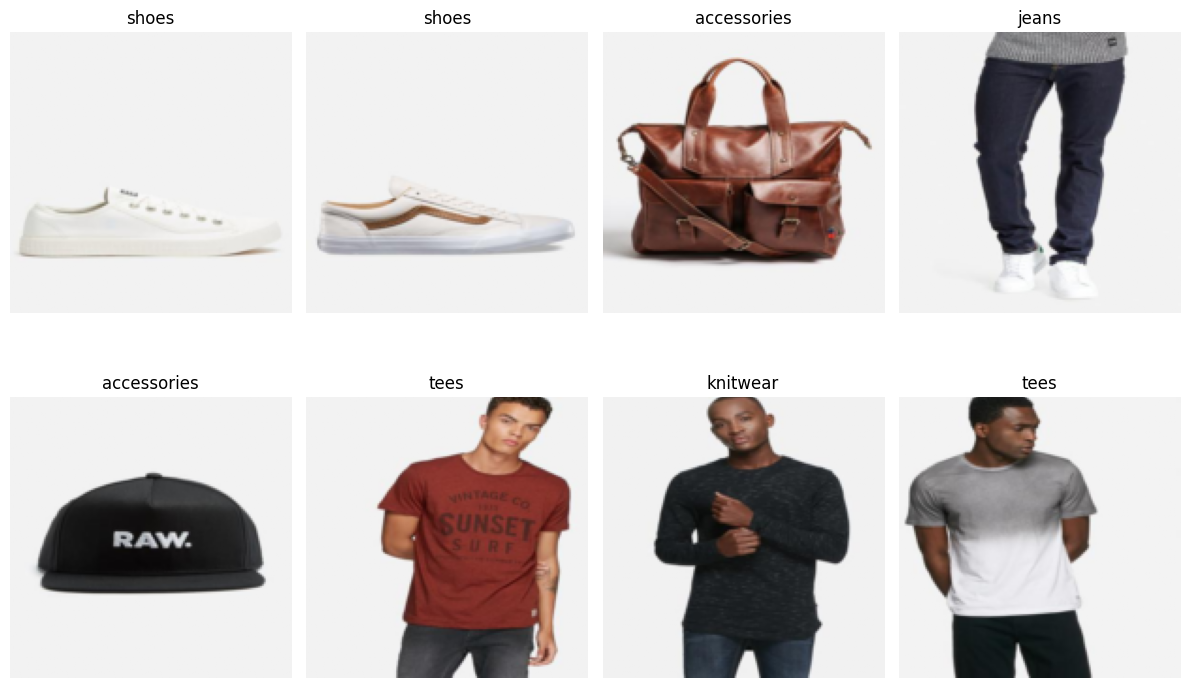

In [12]:
images, labels = next(iter(train_generator))

plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0).numpy())
    plt.title(class_names[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Part 2 — Baseline CNN From Scratch

We now build a first CNN from scratch.  
This model serves as a baseline for all later comparisons.

In [13]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3), nn.ReLU(), nn.MaxPool2d(2),
        )
        # With 150x150 input, this produces 128 channels of 17x17
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 17 * 17, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)  # raw logits, softmax applied inside CrossEntropyLoss
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

baseline_model = BaselineCNN(num_classes).to(device)

In [14]:
total_params = sum(p.numel() for p in baseline_model.parameters())
print(baseline_model)
print(f"Total parameters: {total_params:,}")

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=36992, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=8, bias=True)
  )
)
Total parameters: 9,565,512


In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-4)

In [16]:
# EarlyStopping + ReduceLROnPlateau equivalents
# PyTorch has a built-in scheduler for the "reduce LR on plateau" behaviour,
# but no built-in EarlyStopping callback, so we implement it manually inside the training loop.

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

early_stopping_patience = 5

In [17]:
def evaluate_multiclass(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, scheduler,
                               device, epochs=20, patience=5):
    history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        val_loss, val_acc = evaluate_multiclass(model, val_loader, criterion, device)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        scheduler.step(val_loss)  # ReduceLROnPlateau

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)  # restore_best_weights=True equivalent

    return history

In [18]:
history_baseline = train_with_early_stopping(
    baseline_model, train_generator, validation_generator,
    criterion, optimizer, scheduler, device, epochs=20, patience=5
)

Epoch 1/20 - loss: 1.3208 - accuracy: 0.5495 - val_loss: 0.8064 - val_accuracy: 0.7251
Epoch 2/20 - loss: 0.7284 - accuracy: 0.7312 - val_loss: 0.6120 - val_accuracy: 0.7696
Epoch 3/20 - loss: 0.5985 - accuracy: 0.7808 - val_loss: 0.5124 - val_accuracy: 0.8141
Epoch 4/20 - loss: 0.5059 - accuracy: 0.8134 - val_loss: 0.4651 - val_accuracy: 0.8246
Epoch 5/20 - loss: 0.4606 - accuracy: 0.8292 - val_loss: 0.4282 - val_accuracy: 0.8586
Epoch 6/20 - loss: 0.4131 - accuracy: 0.8506 - val_loss: 0.3729 - val_accuracy: 0.8586
Epoch 7/20 - loss: 0.3822 - accuracy: 0.8480 - val_loss: 0.3256 - val_accuracy: 0.8953
Epoch 8/20 - loss: 0.3510 - accuracy: 0.8682 - val_loss: 0.3259 - val_accuracy: 0.8979
Epoch 9/20 - loss: 0.3191 - accuracy: 0.8789 - val_loss: 0.2981 - val_accuracy: 0.9084
Epoch 10/20 - loss: 0.3015 - accuracy: 0.8858 - val_loss: 0.3205 - val_accuracy: 0.8874
Epoch 11/20 - loss: 0.2828 - accuracy: 0.8936 - val_loss: 0.2698 - val_accuracy: 0.9162
Epoch 12/20 - loss: 0.2584 - accuracy: 0.

# Analyze the Learning Curves

Look at both **accuracy** and **loss** on training and validation sets.

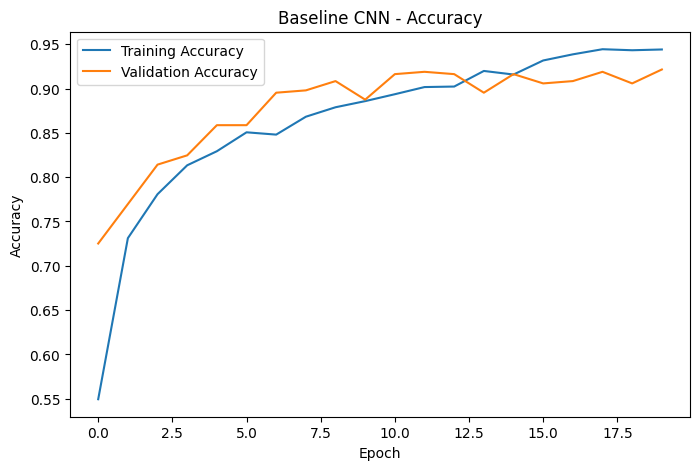

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline["accuracy"], label="Training Accuracy")
plt.plot(history_baseline["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN - Accuracy")
plt.legend()
plt.show()

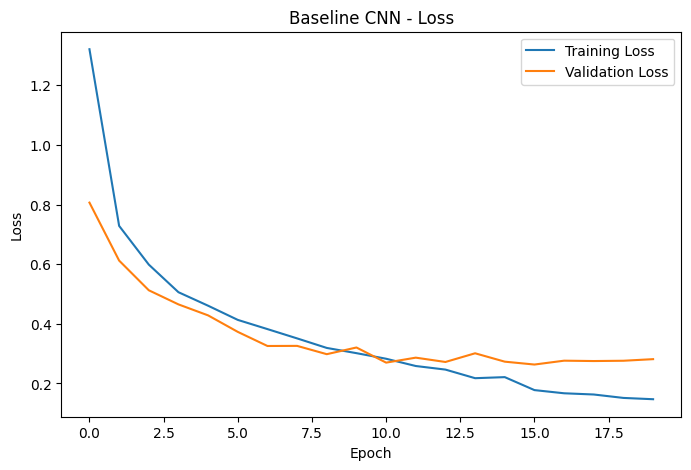

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline["loss"], label="Training Loss")
plt.plot(history_baseline["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN - Loss")
plt.legend()
plt.show()

# Part 3 — Evaluation on the Validation Set

Because the `test/unknown` folder has **no labels**, we use the **validation set** for detailed evaluation:
- loss
- accuracy
- confusion matrix
- classification report
- error analysis

The unknown test images will be used later only for **prediction / inference**.

In [21]:
val_loss_baseline, val_acc_baseline = evaluate_multiclass(baseline_model, validation_generator, criterion, device)

print("Baseline Validation Loss:", val_loss_baseline)
print("Baseline Validation Accuracy:", val_acc_baseline)

Baseline Validation Loss: 0.26337605140157316
Baseline Validation Accuracy: 0.9057591623036649


In [22]:
baseline_model.eval()
all_probs = []
all_true = []

with torch.no_grad():
    for xb, yb in validation_generator:
        xb = xb.to(device)
        logits = baseline_model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_true.append(yb.numpy())

y_pred_probs_baseline = np.concatenate(all_probs)
y_pred_baseline = np.argmax(y_pred_probs_baseline, axis=1)
y_true_val = np.concatenate(all_true)

ordered_class_names = [name for name, idx in sorted(validation_dataset.class_to_idx.items(), key=lambda x: x[1])]

print("Number of validation samples:", len(y_true_val))
print("Ordered class names:", ordered_class_names)

Number of validation samples: 382
Ordered class names: ['accessories', 'jackets', 'jeans', 'knitwear', 'shirts', 'shoes', 'shorts', 'tees']


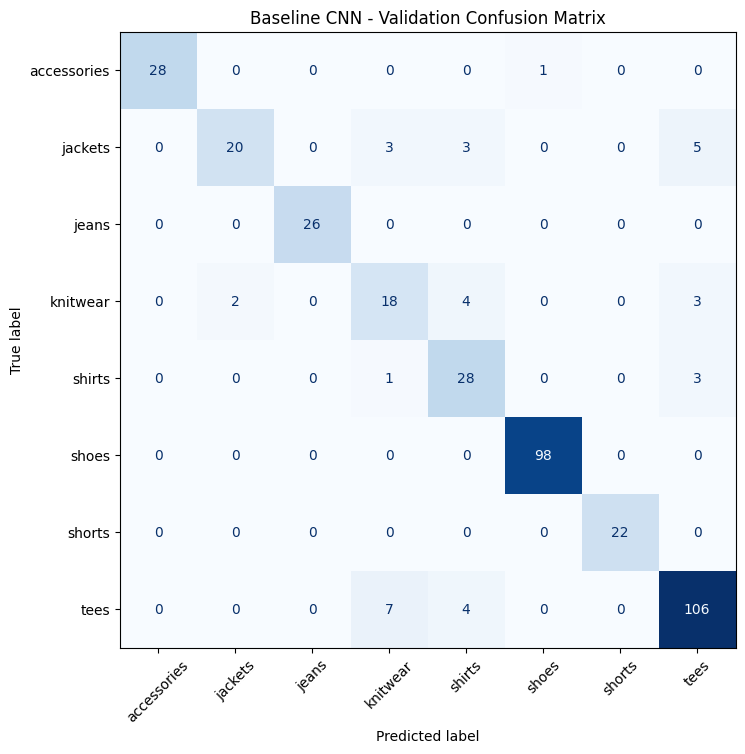

In [23]:
cm_baseline = confusion_matrix(
    y_true_val,
    y_pred_baseline,
    labels=list(range(len(ordered_class_names)))
)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=ordered_class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Baseline CNN - Validation Confusion Matrix")
plt.show()

In [24]:
print(classification_report(
    y_true_val,
    y_pred_baseline,
    labels=list(range(len(ordered_class_names))),
    target_names=ordered_class_names
))

              precision    recall  f1-score   support

 accessories       1.00      0.97      0.98        29
     jackets       0.91      0.65      0.75        31
       jeans       1.00      1.00      1.00        26
    knitwear       0.62      0.67      0.64        27
      shirts       0.72      0.88      0.79        32
       shoes       0.99      1.00      0.99        98
      shorts       1.00      1.00      1.00        22
        tees       0.91      0.91      0.91       117

    accuracy                           0.91       382
   macro avg       0.89      0.88      0.88       382
weighted avg       0.91      0.91      0.91       382



# Visualize Validation Predictions

Let us inspect a few correct and incorrect predictions on the validation set.

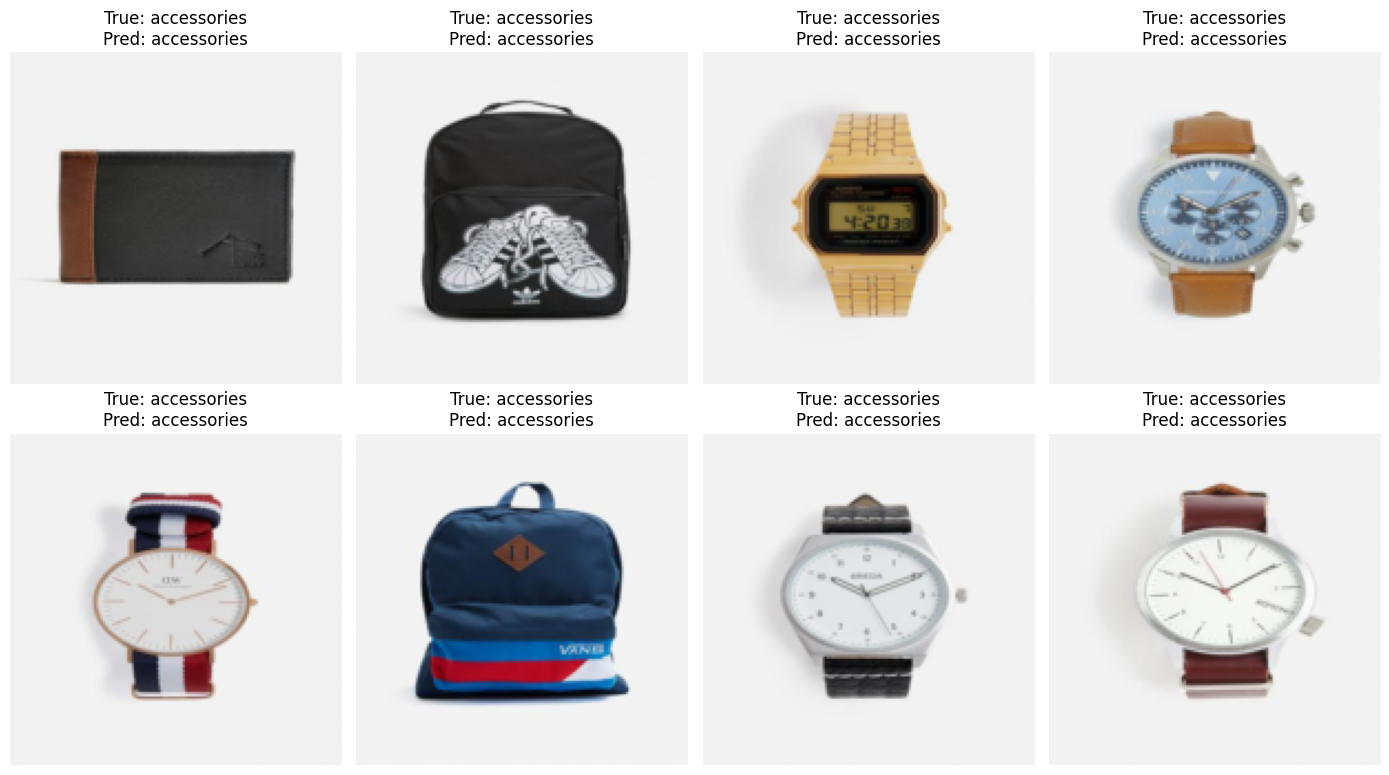

In [25]:
sample_images, sample_labels = next(iter(validation_generator))
with torch.no_grad():
    sample_probs = torch.softmax(baseline_model(sample_images.to(device)), dim=1).cpu().numpy()
sample_preds = np.argmax(sample_probs, axis=1)

plt.figure(figsize=(14, 8))
for i in range(min(8, len(sample_images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_images[i].permute(1, 2, 0).numpy())
    true_label = ordered_class_names[sample_labels[i].item()]
    pred_label = ordered_class_names[sample_preds[i]]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

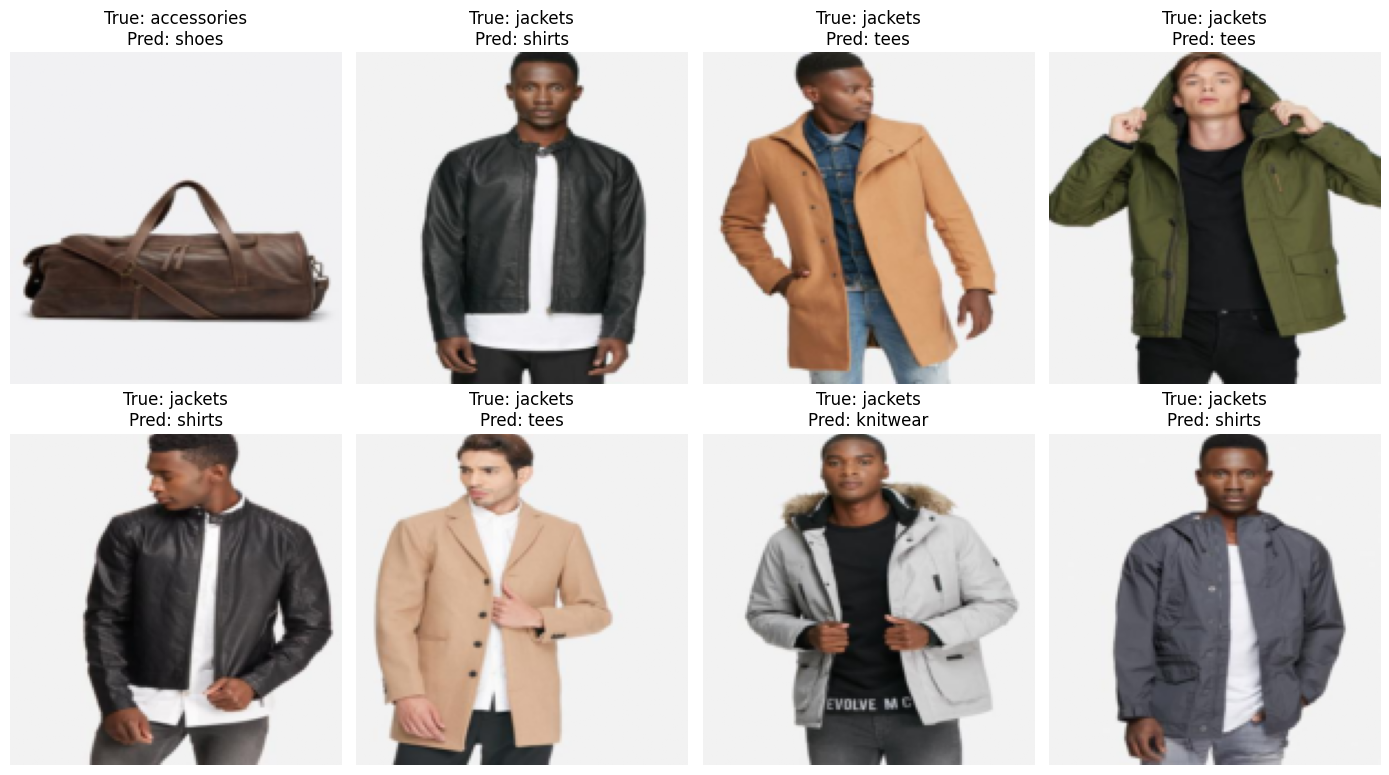

In [26]:
all_val_images = []
for xb, yb in validation_generator:
    all_val_images.append(xb.numpy())
all_val_images = np.vstack(all_val_images)

misclassified_idx = np.where(y_pred_baseline != y_true_val)[0]

plt.figure(figsize=(14, 8))
for i, idx in enumerate(misclassified_idx[:8]):
    plt.subplot(2, 4, i + 1)
    plt.imshow(np.transpose(all_val_images[idx], (1, 2, 0)))
    true_label = ordered_class_names[y_true_val[idx]]
    pred_label = ordered_class_names[y_pred_baseline[idx]]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Part 4 — Improve the Baseline with Data Augmentation

Data augmentation helps the model generalize better by showing slightly modified versions of training images.

In [27]:
train_transform_aug = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop((img_height, img_width), scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

validation_transform_aug = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
])

In [28]:
train_dataset_aug = datasets.ImageFolder(train_dir, transform=train_transform_aug)
validation_dataset_aug = datasets.ImageFolder(validation_dir, transform=validation_transform_aug)

train_generator_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
validation_generator_aug = DataLoader(validation_dataset_aug, batch_size=batch_size, shuffle=False)

In [29]:
augmented_model = BaselineCNN(num_classes).to(device)

criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = optim.Adam(augmented_model.parameters(), lr=1e-4)
scheduler_aug = optim.lr_scheduler.ReduceLROnPlateau(optimizer_aug, mode="min", factor=0.5, patience=3)

In [30]:
history_augmented = train_with_early_stopping(
    augmented_model, train_generator_aug, validation_generator_aug,
    criterion_aug, optimizer_aug, scheduler_aug, device, epochs=20, patience=5
)

Epoch 1/20 - loss: 1.5349 - accuracy: 0.4892 - val_loss: 0.9957 - val_accuracy: 0.6597
Epoch 2/20 - loss: 0.9835 - accuracy: 0.6412 - val_loss: 0.8074 - val_accuracy: 0.7199
Epoch 3/20 - loss: 0.8327 - accuracy: 0.7055 - val_loss: 0.6599 - val_accuracy: 0.7592
Epoch 4/20 - loss: 0.7214 - accuracy: 0.7479 - val_loss: 0.5549 - val_accuracy: 0.8063
Epoch 5/20 - loss: 0.6587 - accuracy: 0.7742 - val_loss: 0.5059 - val_accuracy: 0.8246
Epoch 6/20 - loss: 0.6132 - accuracy: 0.7710 - val_loss: 0.4800 - val_accuracy: 0.8298
Epoch 7/20 - loss: 0.5871 - accuracy: 0.7906 - val_loss: 0.4597 - val_accuracy: 0.8508
Epoch 8/20 - loss: 0.5510 - accuracy: 0.7955 - val_loss: 0.4440 - val_accuracy: 0.8377
Epoch 9/20 - loss: 0.5442 - accuracy: 0.8085 - val_loss: 0.4468 - val_accuracy: 0.8482
Epoch 10/20 - loss: 0.5250 - accuracy: 0.8108 - val_loss: 0.4218 - val_accuracy: 0.8560
Epoch 11/20 - loss: 0.5183 - accuracy: 0.8160 - val_loss: 0.4038 - val_accuracy: 0.8639
Epoch 12/20 - loss: 0.4906 - accuracy: 0.

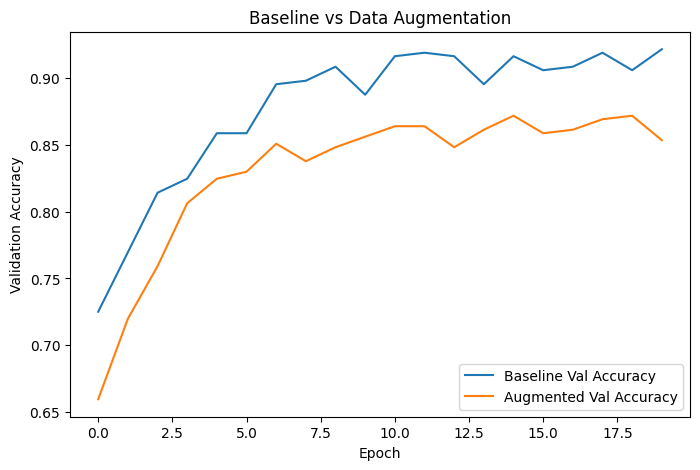

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline["val_accuracy"], label="Baseline Val Accuracy")
plt.plot(history_augmented["val_accuracy"], label="Augmented Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Baseline vs Data Augmentation")
plt.legend()
plt.show()

In [32]:
val_loss_aug, val_acc_aug = evaluate_multiclass(augmented_model, validation_generator_aug, criterion_aug, device)
print("Augmented Model Validation Loss:", val_loss_aug)
print("Augmented Model Validation Accuracy:", val_acc_aug)

Augmented Model Validation Loss: 0.3448493789627914
Augmented Model Validation Accuracy: 0.8691099476439791


# Part 5 — Transfer Learning with MobileNetV2

Instead of learning everything from scratch, we can reuse features learned on ImageNet.
This often works well when the dataset is not huge.

> Note: torchvision's pretrained MobileNetV2 expects the standard ImageNet normalization (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) rather than Keras's `preprocess_input` (which scales pixels to `[-1, 1]`). This is a difference between the two frameworks' pretrained weights, not a lab error.

In [33]:
img_height_tl = 224
img_width_tl = 224

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform_tl = transforms.Compose([
    transforms.Resize((img_height_tl, img_width_tl)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

validation_transform_tl = transforms.Compose([
    transforms.Resize((img_height_tl, img_width_tl)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [34]:
train_dataset_tl = datasets.ImageFolder(train_dir, transform=train_transform_tl)
validation_dataset_tl = datasets.ImageFolder(validation_dir, transform=validation_transform_tl)

train_generator_tl = DataLoader(train_dataset_tl, batch_size=batch_size, shuffle=True)
validation_generator_tl = DataLoader(validation_dataset_tl, batch_size=batch_size, shuffle=False)

In [35]:
base_model = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
base_model = base_model.features  # convolutional feature extractor only (no top classifier)

for param in base_model.parameters():
    param.requires_grad = False

class TransferModel(nn.Module):
    def __init__(self, base_model, num_classes):
        super().__init__()
        self.base_model = base_model
        self.pool = nn.AdaptiveAvgPool2d(1)  # GlobalAveragePooling2D equivalent
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.base_model(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

transfer_model = TransferModel(base_model, num_classes).to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 126MB/s]


In [36]:
total_params = sum(p.numel() for p in transfer_model.parameters())
trainable_params = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 2,388,872
Trainable parameters: 165,000


In [37]:
criterion_tl = nn.CrossEntropyLoss()
optimizer_tl = optim.Adam(transfer_model.parameters(), lr=1e-4)
scheduler_tl = optim.lr_scheduler.ReduceLROnPlateau(optimizer_tl, mode="min", factor=0.5, patience=3)

In [38]:
history_transfer = train_with_early_stopping(
    transfer_model, train_generator_tl, validation_generator_tl,
    criterion_tl, optimizer_tl, scheduler_tl, device, epochs=15, patience=5
)

Epoch 1/15 - loss: 1.4222 - accuracy: 0.5547 - val_loss: 0.8992 - val_accuracy: 0.6780
Epoch 2/15 - loss: 0.7550 - accuracy: 0.7868 - val_loss: 0.5107 - val_accuracy: 0.8691
Epoch 3/15 - loss: 0.5197 - accuracy: 0.8621 - val_loss: 0.3821 - val_accuracy: 0.9031
Epoch 4/15 - loss: 0.4067 - accuracy: 0.8843 - val_loss: 0.3046 - val_accuracy: 0.9031
Epoch 5/15 - loss: 0.3483 - accuracy: 0.8985 - val_loss: 0.2697 - val_accuracy: 0.9215
Epoch 6/15 - loss: 0.3052 - accuracy: 0.9068 - val_loss: 0.2509 - val_accuracy: 0.9188
Epoch 7/15 - loss: 0.2936 - accuracy: 0.9164 - val_loss: 0.2249 - val_accuracy: 0.9372
Epoch 8/15 - loss: 0.2673 - accuracy: 0.9164 - val_loss: 0.2096 - val_accuracy: 0.9372
Epoch 9/15 - loss: 0.2416 - accuracy: 0.9204 - val_loss: 0.1990 - val_accuracy: 0.9372
Epoch 10/15 - loss: 0.2373 - accuracy: 0.9195 - val_loss: 0.1935 - val_accuracy: 0.9424
Epoch 11/15 - loss: 0.2252 - accuracy: 0.9299 - val_loss: 0.1903 - val_accuracy: 0.9346
Epoch 12/15 - loss: 0.2202 - accuracy: 0.

In [39]:
val_loss_transfer, val_acc_transfer = evaluate_multiclass(transfer_model, validation_generator_tl, criterion_tl, device)
print("Transfer Learning Validation Loss:", val_loss_transfer)
print("Transfer Learning Validation Accuracy:", val_acc_transfer)

Transfer Learning Validation Loss: 0.17303130658665253
Transfer Learning Validation Accuracy: 0.9397905759162304


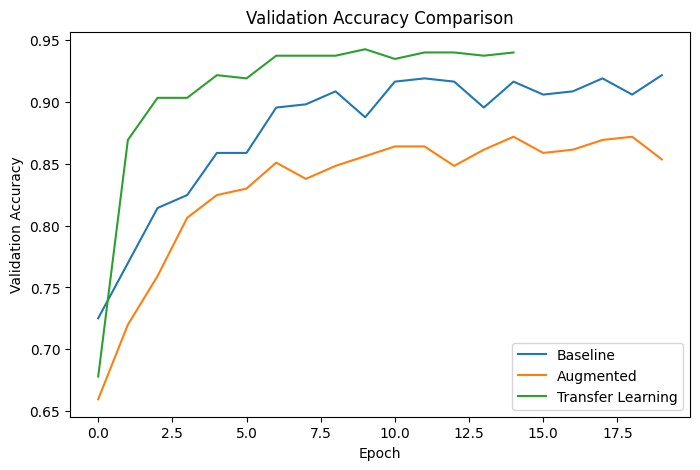

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline["val_accuracy"], label="Baseline")
plt.plot(history_augmented["val_accuracy"], label="Augmented")
plt.plot(history_transfer["val_accuracy"], label="Transfer Learning")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

# Part 6 — Fine-Tuning the Pre-Trained Model

Once the classifier on top is trained, we can unfreeze a few higher layers of the pre-trained model and continue training with a very small learning rate.

> Note: torchvision's MobileNetV2 `features` module is organized as a sequence of building blocks rather than the flat layer list Keras exposes, so "unfreeze the last 30 layers" is adapted here to "unfreeze the last few blocks", which plays the same role.

In [41]:
for param in transfer_model.base_model.parameters():
    param.requires_grad = True

# Freeze all blocks except the last 4 (approx. equivalent to unfreezing the last ~30 layers in Keras)
blocks = list(transfer_model.base_model.children())
for block in blocks[:-4]:
    for param in block.parameters():
        param.requires_grad = False

trainable_blocks = sum(1 for block in blocks[-4:] for _ in block.parameters())
print("Number of trainable parameter tensors in the last blocks:", trainable_blocks)

Number of trainable parameter tensors in the last blocks: 30


In [42]:
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, transfer_model.parameters()), lr=1e-5)
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode="min", factor=0.5, patience=3)
criterion_ft = nn.CrossEntropyLoss()

In [43]:
history_finetune = train_with_early_stopping(
    transfer_model, train_generator_tl, validation_generator_tl,
    criterion_ft, optimizer_ft, scheduler_ft, device, epochs=10, patience=5
)

Epoch 1/10 - loss: 0.1874 - accuracy: 0.9334 - val_loss: 0.1501 - val_accuracy: 0.9450
Epoch 2/10 - loss: 0.1511 - accuracy: 0.9475 - val_loss: 0.1406 - val_accuracy: 0.9529
Epoch 3/10 - loss: 0.1333 - accuracy: 0.9550 - val_loss: 0.1324 - val_accuracy: 0.9607
Epoch 4/10 - loss: 0.1164 - accuracy: 0.9605 - val_loss: 0.1316 - val_accuracy: 0.9555
Epoch 5/10 - loss: 0.1128 - accuracy: 0.9631 - val_loss: 0.1273 - val_accuracy: 0.9529
Epoch 6/10 - loss: 0.0955 - accuracy: 0.9663 - val_loss: 0.1207 - val_accuracy: 0.9607
Epoch 7/10 - loss: 0.0848 - accuracy: 0.9755 - val_loss: 0.1217 - val_accuracy: 0.9581
Epoch 8/10 - loss: 0.0814 - accuracy: 0.9749 - val_loss: 0.1168 - val_accuracy: 0.9581
Epoch 9/10 - loss: 0.0640 - accuracy: 0.9792 - val_loss: 0.1159 - val_accuracy: 0.9660
Epoch 10/10 - loss: 0.0668 - accuracy: 0.9804 - val_loss: 0.1162 - val_accuracy: 0.9555


In [44]:
val_loss_finetune, val_acc_finetune = evaluate_multiclass(transfer_model, validation_generator_tl, criterion_ft, device)
print("Fine-Tuned Model Validation Loss:", val_loss_finetune)
print("Fine-Tuned Model Validation Accuracy:", val_acc_finetune)

Fine-Tuned Model Validation Loss: 0.11590039989477052
Fine-Tuned Model Validation Accuracy: 0.9659685863874345


# Part 7 — Predict Classes for Unlabeled Test Images

Now we use the trained model to predict the classes of the images stored in `data/test/unknown`.

Because these images have **no labels**, this is **inference only**:
- no accuracy
- no confusion matrix
- no classification report

In [45]:
best_model = transfer_model  # change this if another model performed better
best_model_name = "Fine-tuned Transfer Model"  # update if needed
use_transfer_preprocessing = True  # False for baseline/augmented, True for transfer/fine-tuned

print("Selected model for unknown predictions:", best_model_name)

Selected model for unknown predictions: Fine-tuned Transfer Model


In [46]:
unknown_image_files = sorted([
    f for f in os.listdir(unknown_test_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
])

print("Unknown images found:", len(unknown_image_files))
print(unknown_image_files)

Unknown images found: 8
['test1.jpg', 'test2.jpg', 'test3.jpg', 'test4.jpg', 'test5.jpg', 'test6.jpg', 'test7.jpg', 'test8.jpg']


In [47]:
if use_transfer_preprocessing:
    target_h, target_w = img_height_tl, img_width_tl
    predict_transform = transforms.Compose([
        transforms.Resize((target_h, target_w)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])
else:
    target_h, target_w = img_height, img_width
    predict_transform = transforms.Compose([
        transforms.Resize((target_h, target_w)),
        transforms.ToTensor(),
    ])

unknown_tensors = []
unknown_filenames = []

for fname in unknown_image_files:
    path = os.path.join(unknown_test_dir, fname)
    img = Image.open(path).convert("RGB")
    img_tensor = predict_transform(img)
    unknown_tensors.append(img_tensor)
    unknown_filenames.append(fname)

unknown_images = torch.stack(unknown_tensors)

print("Unknown images tensor shape:", unknown_images.shape)

Unknown images tensor shape: torch.Size([8, 3, 224, 224])


In [48]:
best_model.eval()
with torch.no_grad():
    logits_unknown = best_model(unknown_images.to(device))
    pred_probs_unknown = torch.softmax(logits_unknown, dim=1).cpu().numpy()

pred_classes_unknown = np.argmax(pred_probs_unknown, axis=1)
pred_labels_unknown = [ordered_class_names[i] for i in pred_classes_unknown]
pred_confidence_unknown = np.max(pred_probs_unknown, axis=1)

for fname, label, conf in zip(unknown_filenames, pred_labels_unknown, pred_confidence_unknown):
    print(f"{fname} -> {label} ({conf:.2f})")

test1.jpg -> shirts (0.99)
test2.jpg -> shirts (0.99)
test3.jpg -> shoes (0.72)
test4.jpg -> jeans (1.00)
test5.jpg -> jeans (1.00)
test6.jpg -> tees (1.00)
test7.jpg -> tees (0.51)
test8.jpg -> shoes (1.00)


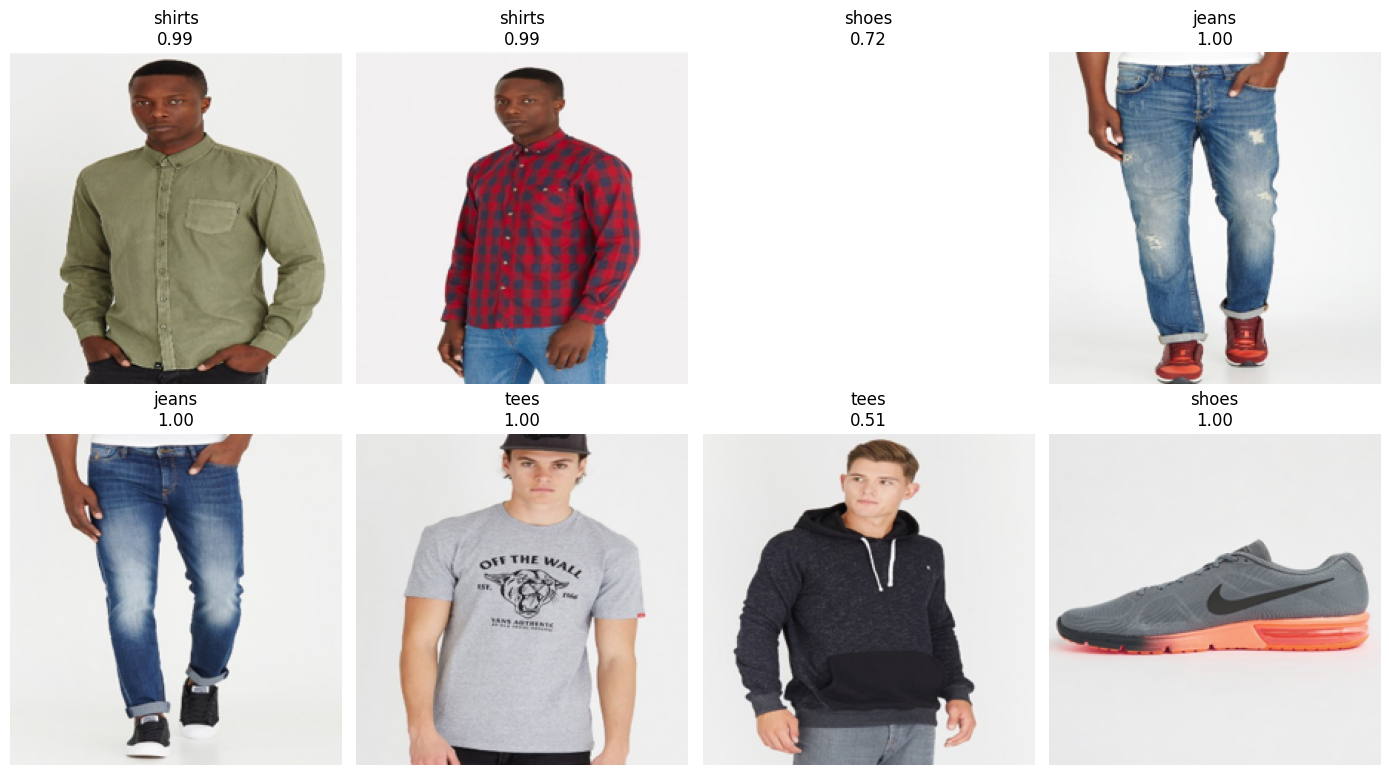

In [49]:
plt.figure(figsize=(14, 8))
for i in range(min(8, len(unknown_images))):
    plt.subplot(2, 4, i + 1)
    display_img = Image.open(os.path.join(unknown_test_dir, unknown_filenames[i])).convert("RGB").resize((target_h, target_w))
    plt.imshow(display_img)
    plt.title(f"{pred_labels_unknown[i]}\n{pred_confidence_unknown[i]:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Part 8 — Model Comparison Summary

Summarize the performance of:
- baseline CNN
- CNN with augmentation
- transfer learning
- fine-tuned transfer learning

Use the **validation set** for comparison, since the unknown test folder has no labels.

In [50]:
results = {
    "Baseline CNN": val_acc_baseline,
    "CNN + Augmentation": val_acc_aug,
    "Transfer Learning": val_acc_transfer,
    "Fine-Tuned Transfer": val_acc_finetune,
}

for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")

Baseline CNN: 0.9058
CNN + Augmentation: 0.8691
Transfer Learning: 0.9398
Fine-Tuned Transfer: 0.9660


# Experimental Extensions

Choose **one or two** of the following extensions:

- increase image size
- try another backbone such as EfficientNetB0 (`torchvision.models.efficientnet_b0`)
- add stronger augmentation
- compare Adam vs RMSprop
- compare `Dropout(0.3)` vs `Dropout(0.5)`
- compute top-2 predictions for unknown images
- train longer with early stopping

# Final Questions

Answer these global questions at the end of the lab:

1. What was the purpose of each major stage of the notebook?
   - baseline CNN
   - validation evaluation
   - data augmentation
   - transfer learning
   - fine-tuning
   - prediction on unknown images

2. Which model performed best on the validation set, and why do you think it worked better?

3. What signs of overfitting or underfitting did you observe during training?

4. Did data augmentation help in your case? Explain your answer using the validation curves.

5. How did transfer learning compare with training a CNN from scratch?

6. Did fine-tuning improve the transfer learning model? Why might that happen?

7. Which classes were easiest and hardest to classify on the validation set?

8. What kinds of mistakes did the model make, and were those mistakes understandable visually?

9. Why can we not compute accuracy on the `test/unknown` folder?

10. If you had one more hour to improve the notebook results, what would you try next?

11. What are the main practical differences you noticed between the TensorFlow/Keras workflow (`ImageDataGenerator`, `.fit()`, callbacks) and the PyTorch workflow (`ImageFolder`/`DataLoader`, explicit training loop, manual early stopping)?